# UFC Finish Dynamics (2015-2025)

## Executive summary

### research question / motivation
Your project asks three linked questions:
1. Is the UFC finish environment drifting over time or mostly mean-reverting?
2. Which divisions consistently produce finish-heavy profiles?
3. Can a compact pre-fight model separate likely finishes from likely decisions with enough signal to be useful?

### data source
- scraped from [ufcstats.com](http://ufcstats.com/) event pages using `src/scraping.py`
- fight-level records include event metadata, bout stats, result labels, round/time, and bonus/title indicators
- this notebook uses the modern-era subset from 2015-01-01 through 2025-12-31 and current UFC divisions

### key findings
- aggregate finish rate is stable around the 50% level, with short-term shocks but no sustained trend break
- division context matters: heavier male classes remain finish-forward, while several women's divisions are decision-heavy
- outcome composition is style-specific by weight class (for example, KO-heavy heavyweight vs decision-heavy strawweight)
- logit and probit perform almost identically, so threshold policy is more important than link-function choice

### practical read for this repo
- treat year as a weak context feature, not a primary driver
- preserve division-level structure in any deployment model
- tune thresholds to your objective (maximize recall of finishes vs reduce false alarms)


## 1) setup

In [1]:
from pathlib import Path
import sys
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.analysis_utils import (
    DEFAULT_HEATMAP_ORDER,
    DEFAULT_OUTCOME_ORDER,
    build_calibration_table,
    compute_auc_curves,
    compute_confusion_metrics,
    compute_division_finish_rates,
    compute_outcome_mix_by_division,
    compute_yearly_finish_stats,
    confusion_matrix_df,
    fit_finish_models,
    get_project_root,
    load_fight_data,
    prepare_analysis_frame,
    save_processed_data,
)

logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
sns.set_theme(style="whitegrid", context="talk")

project_root = get_project_root()
figs_dir = project_root / "figs"
figs_dir.mkdir(parents=True, exist_ok=True)

EXPECTED_FIGURES = [
    "finish_rate_trend.png",
    "division_finish_heatmap.png",
    "division_outcome_mix.png",
    "model_calibration.png",
    "roc_logit_probit.png",
    "confusion_logit_probit.png",
]

def save_figure(fig, filename: str, dpi: int = 200) -> Path:
    path = figs_dir / filename
    fig.savefig(path, dpi=dpi, bbox_inches="tight", facecolor="white")
    return path


## 2) load and prepare data

In [2]:
raw_df = load_fight_data()
df = prepare_analysis_frame(raw_df, start_date="2015-01-01", end_date="2026-01-01")
processed_path = save_processed_data(df)

print(f"rows in analysis frame: {len(df):,}")
print(f"year span: {df['Year'].min()}-{df['Year'].max()}")
print(f"processed snapshot saved to: {processed_path}")

df.head()

INFO | loading dataset from /Users/juanvilla/Documents/Personal-Projects/Project-Jan-2025/ufc-analytics/data/processed/ufc_event_data.csv


INFO | saved processed dataset to /Users/juanvilla/Documents/Personal-Projects/Project-Jan-2025/ufc-analytics/data/processed/ufc_event_data.csv


rows in analysis frame: 5,353
year span: 2015-2025
processed snapshot saved to: /Users/juanvilla/Documents/Personal-Projects/Project-Jan-2025/ufc-analytics/data/processed/ufc_event_data.csv


,Event,Date,Location,WL,Fighter_A,Fighter_B,Fighter_A_KD,Fighter_B_KD,Fighter_A_STR,Fighter_B_STR,...,Round,Time,Weight_Class,Title,Fight_Bonus,Perf_Bonus,Sub_Bonus,KO_Bonus,Year,Outcome
0,UFC Fight Night: Royval vs. Kape,2025-12-13,"Las Vegas, Nevada, USA",WIN,Manel Kape,Brandon Royval,1,0,17,17,...,1,3:18,Flyweight,0,0,1,0,0,2025,KO
1,UFC Fight Night: Royval vs. Kape,2025-12-13,"Las Vegas, Nevada, USA",WIN,Kevin Vallejos,Giga Chikadze,1,0,20,12,...,2,1:29,Featherweight,0,0,1,0,0,2025,KO
2,UFC Fight Night: Royval vs. Kape,2025-12-13,"Las Vegas, Nevada, USA",WIN,Cezary Oleksiejczuk,Cesar Almeida,0,0,14,12,...,3,5:00,Middleweight,0,0,0,0,0,2025,UDEC
3,UFC Fight Night: Royval vs. Kape,2025-12-13,"Las Vegas, Nevada, USA",WIN,Melquizael Costa,Morgan Charriere,1,0,4,2,...,1,1:14,Featherweight,0,0,0,0,0,2025,KO
4,UFC Fight Night: Royval vs. Kape,2025-12-13,"Las Vegas, Nevada, USA",DRAW DRAW,Kennedy Nzechukwu,Marcus Buchecha,0,0,24,27,...,3,5:00,Heavyweight,0,0,0,0,0,2025,UDEC


## 3) how has the overall finish rate changed over time?

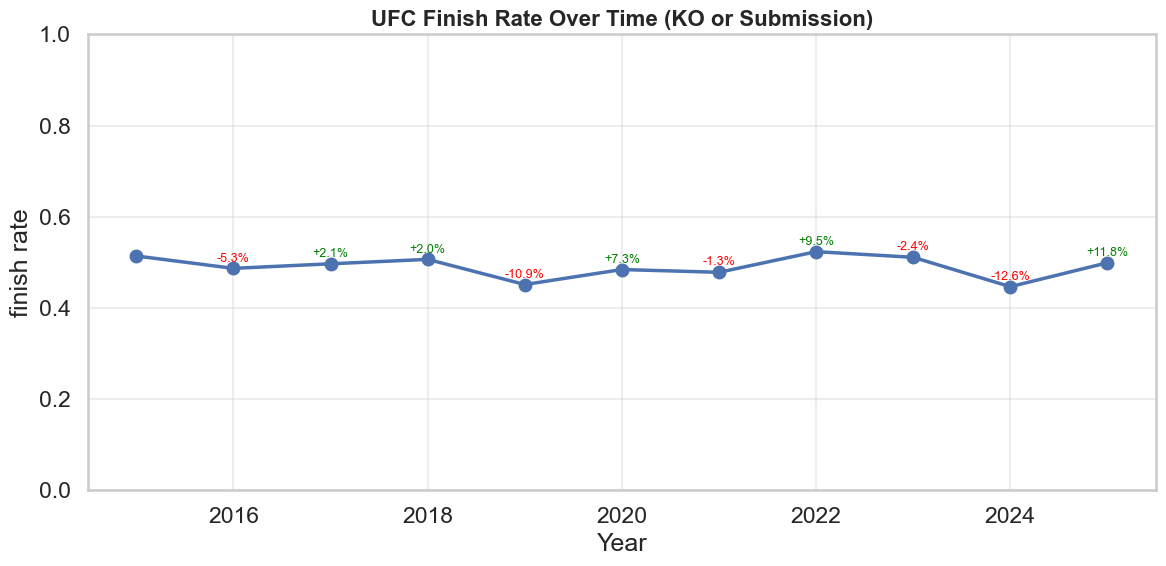

saved: figs/finish_rate_trend.png


In [3]:
yearly_stats = compute_yearly_finish_stats(df)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(yearly_stats.index, yearly_stats["Finish_Rate"], marker="o", linewidth=2.5)

for year, finish_rate, pct_change in zip(
    yearly_stats.index[1:],
    yearly_stats["Finish_Rate"].iloc[1:],
    yearly_stats["Finish_Rate_Change_Pct"].iloc[1:],
):
    if pd.notna(pct_change):
        color = "green" if pct_change > 0 else "red"
        ax.text(year, finish_rate + 0.015, f"{pct_change:+.1f}%", ha="center", fontsize=9, color=color)

ax.set_title("UFC Finish Rate Over Time (KO or Submission)", fontsize=16, weight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("finish rate")
ax.set_ylim(0, 1)
ax.grid(alpha=0.35)
fig.tight_layout()
saved_path = save_figure(fig, "finish_rate_trend.png")
plt.show()
print(f"saved: {saved_path.relative_to(project_root)}")


In [4]:
largest_increase_year = int(yearly_stats["Finish_Rate_Change_Pct"].idxmax())
largest_decrease_year = int(yearly_stats["Finish_Rate_Change_Pct"].idxmin())
latest_year = int(yearly_stats.index.max())
latest_rate = yearly_stats.loc[latest_year, "Finish_Rate"]
window_mean = yearly_stats["Finish_Rate"].mean()
window_std = yearly_stats["Finish_Rate"].std()

summary = f"""
Across the full window, yearly finish rates mostly sit inside a tight operating band around **{window_mean:.3f}** (std **{window_std:.3f}**).  
The sharpest upswing occurred in **{largest_increase_year}** ({yearly_stats.loc[largest_increase_year, 'Finish_Rate_Change_Pct']:+.1f}% year over year), while the sharpest drop landed in **{largest_decrease_year}** ({yearly_stats.loc[largest_decrease_year, 'Finish_Rate_Change_Pct']:+.1f}%).  
For your project, that pattern means this is a *volatility* story more than a trend story: in **{latest_year}**, finish rate is **{latest_rate:.3f}**, and calendar year alone should be treated as context, not a primary signal.
"""
display(Markdown(summary))



Across the full window, yearly finish rates mostly sit inside a tight operating band around **0.491** (std **0.025**).  
The sharpest upswing occurred in **2025** (+11.8% year over year), while the sharpest drop landed in **2024** (-12.6%).  
For your project, that pattern means this is a *volatility* story more than a trend story: in **2025**, finish rate is **0.499**, and calendar year alone should be treated as context, not a primary signal.


## 4) which divisions finish most often?

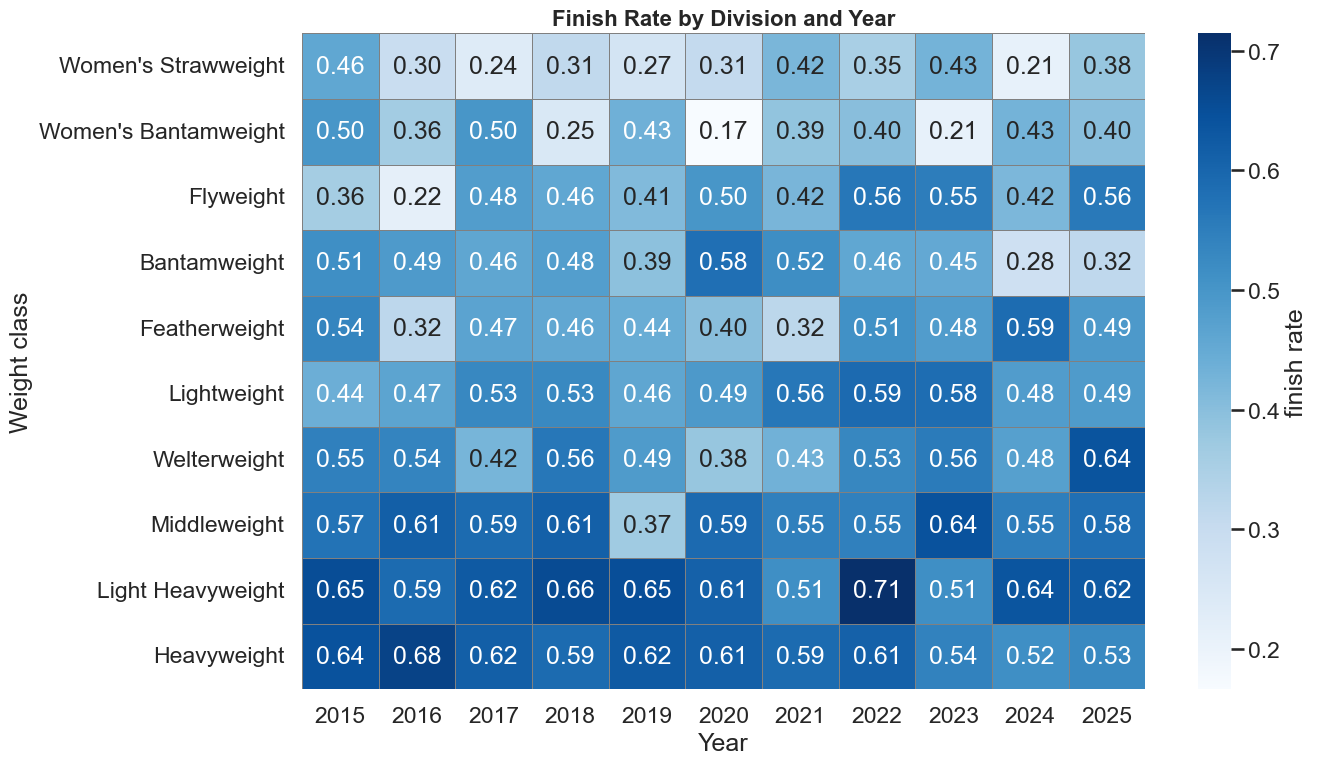

saved: figs/division_finish_heatmap.png


In [5]:
heatmap_data = compute_division_finish_rates(df, weight_order=DEFAULT_HEATMAP_ORDER)

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    heatmap_data,
    cmap="Blues",
    annot=True,
    fmt=".2f",
    linewidths=0.4,
    linecolor="gray",
    cbar_kws={"label": "finish rate"},
    ax=ax,
)
ax.set_title("Finish Rate by Division and Year", fontsize=16, weight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Weight class")
fig.tight_layout()
saved_path = save_figure(fig, "division_finish_heatmap.png")
plt.show()
print(f"saved: {saved_path.relative_to(project_root)}")


In [6]:
division_mean_rates = heatmap_data.mean(axis=1).dropna().sort_values(ascending=False)
top_division = division_mean_rates.index[0]
bottom_division = division_mean_rates.index[-1]
spread_pp = (division_mean_rates.iloc[0] - division_mean_rates.iloc[-1]) * 100

top3 = ", ".join([f"{idx} ({val:.3f})" for idx, val in division_mean_rates.head(3).items()])
bottom3 = ", ".join([f"{idx} ({val:.3f})" for idx, val in division_mean_rates.tail(3).items()])

summary = f"""
Division effects are large, not marginal: average finish-rate spread from top to bottom class is **{spread_pp:.1f} percentage points**.  
Top three finish-heavy groups are **{top3}**; the most decision-leaning tier is **{bottom3}**.  
That ranking argues for division-specific baselines in any forecasting workflow, because the environment in **{top_division}** is materially different from **{bottom_division}** before you even look at fighter-level inputs.
"""
display(Markdown(summary))



Division effects are large, not marginal: average finish-rate spread from top to bottom class is **28.4 percentage points**.  
Top three finish-heavy groups are **Light Heavyweight (0.618), Heavyweight (0.595), Middleweight (0.565)**; the most decision-leaning tier is **Bantamweight (0.450), Women's Bantamweight (0.368), Women's Strawweight (0.334)**.  
That ranking argues for division-specific baselines in any forecasting workflow, because the environment in **Light Heavyweight** is materially different from **Women's Strawweight** before you even look at fighter-level inputs.


## 5) how do finish types differ across divisions?

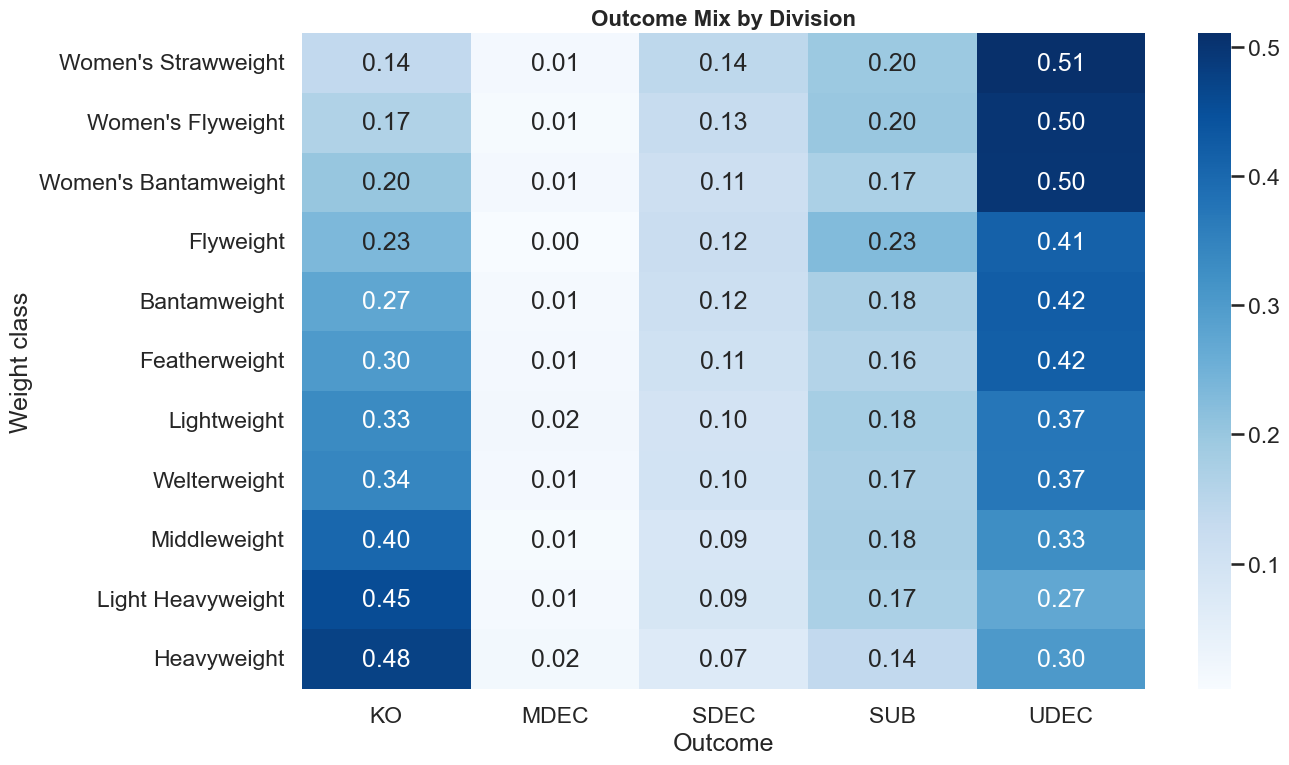

saved: figs/division_outcome_mix.png


In [7]:
outcome_mix = compute_outcome_mix_by_division(df, weight_order=DEFAULT_OUTCOME_ORDER)

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(outcome_mix, annot=True, fmt=".2f", cmap="Blues", ax=ax)
ax.set_title("Outcome Mix by Division", fontsize=16, weight="bold")
ax.set_xlabel("Outcome")
ax.set_ylabel("Weight class")
fig.tight_layout()
saved_path = save_figure(fig, "division_outcome_mix.png")
plt.show()
print(f"saved: {saved_path.relative_to(project_root)}")


In [8]:
heavyweight_ko = outcome_mix.loc["Heavyweight", "KO"]
heavyweight_udec = outcome_mix.loc["Heavyweight", "UDEC"]
straw_ko = outcome_mix.loc["Women's Strawweight", "KO"]
straw_udec = outcome_mix.loc["Women's Strawweight", "UDEC"]

summary = f"""
The class contrast is structural. **Heavyweight** is KO-forward (KO share **{heavyweight_ko:.3f}**) with limited unanimous-decision volume (**{heavyweight_udec:.3f}**).  
**Women's Strawweight** shows the reverse profile (KO share **{straw_ko:.3f}**, UDEC share **{straw_udec:.3f}**).  
For your analysis narrative, this is a key insight: finish-rate differences are not just "more vs less finishing"; they reflect different *finish mechanisms* by division.
"""
display(Markdown(summary))



The class contrast is structural. **Heavyweight** is KO-forward (KO share **0.476**) with limited unanimous-decision volume (**0.303**).  
**Women's Strawweight** shows the reverse profile (KO share **0.137**, UDEC share **0.510**).  
For your analysis narrative, this is a key insight: finish-rate differences are not just "more vs less finishing"; they reflect different *finish mechanisms* by division.


## 6) predictive modeling: logit vs probit for finish probability

In [9]:
bundle = fit_finish_models(df)
auc_payload = compute_auc_curves(bundle)

model_summary = pd.DataFrame(
    {
        "metric": ["observations", "logit pseudo r2", "probit pseudo r2", "logit auc", "probit auc"],
        "value": [
            len(bundle.y),
            bundle.logit_model.prsquared,
            1 - (bundle.probit_model.llf / bundle.probit_model.llnull),
            auc_payload["auc_logit"],
            auc_payload["auc_probit"],
        ],
    }
)
model_summary

,metric,value
0,observations,5353.000000
1,logit pseudo r2,0.559338
2,probit pseudo r2,0.537774
3,logit auc,0.940894
4,probit auc,0.940411


In [10]:
key_terms = [
    "Round",
    "Title",
    "Total_KD",
    "Total_SIG_STR",
    "Total_TD",
    "Total_SUB_ATT",
    "SIG_STR_DIFF_ABS",
]

coef_table = pd.DataFrame(
    {
        "coef": bundle.logit_model.params[key_terms],
        "p_value": bundle.logit_model.pvalues[key_terms],
    }
)
coef_table["odds_ratio"] = np.exp(coef_table["coef"])
coef_table.sort_values("p_value")

,coef,p_value,odds_ratio
Round,-2.883942,9.083498e-166,0.055914
Total_KD,1.032676,2.372835e-44,2.808572
Title,4.569682,6.373086e-38,96.513437
Total_SUB_ATT,0.384810,1.208225e-19,1.469336
SIG_STR_DIFF_ABS,0.015038,1.115695e-09,1.015151
Total_SIG_STR,-0.006199,9.474034e-08,0.993820
Total_TD,-0.078139,8.299865e-04,0.924836


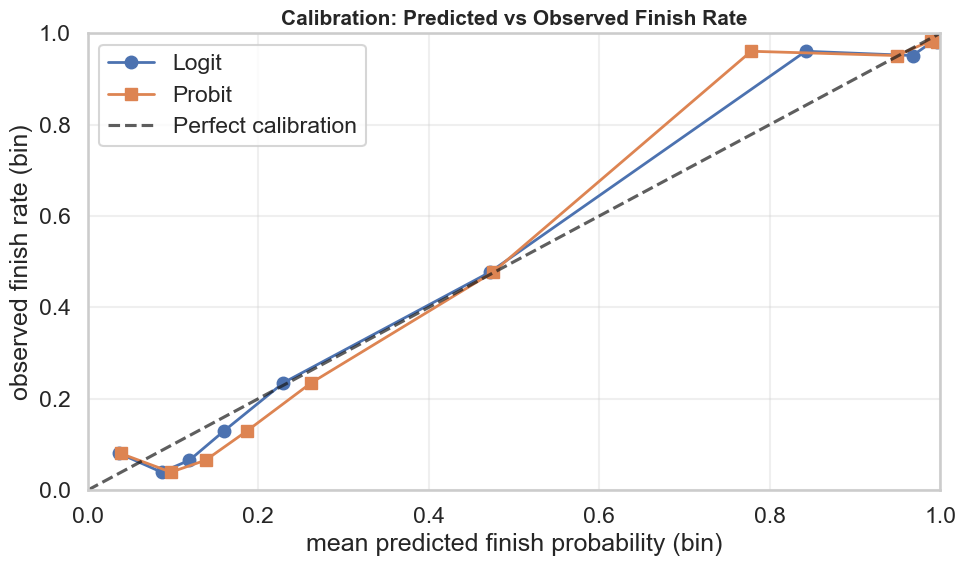

saved: figs/model_calibration.png


In [11]:
calibration = build_calibration_table(bundle)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(calibration["Logit_Pred"], calibration["Observed_Finish"], marker="o", linewidth=2, label="Logit")
ax.plot(calibration["Probit_Pred"], calibration["Observed_Finish"], marker="s", linewidth=2, label="Probit")
ax.plot([0, 1], [0, 1], "k--", alpha=0.7, label="Perfect calibration")
ax.set_title("Calibration: Predicted vs Observed Finish Rate", fontsize=15, weight="bold")
ax.set_xlabel("mean predicted finish probability (bin)")
ax.set_ylabel("observed finish rate (bin)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
saved_path = save_figure(fig, "model_calibration.png")
plt.show()
print(f"saved: {saved_path.relative_to(project_root)}")


In [12]:
calibration = calibration.copy()
calibration["logit_error"] = calibration["Observed_Finish"] - calibration["Logit_Pred"]
calibration["probit_error"] = calibration["Observed_Finish"] - calibration["Probit_Pred"]

logit_mae = calibration["logit_error"].abs().mean()
probit_mae = calibration["probit_error"].abs().mean()

summary = f"""
Calibration is strong overall, and the two link functions are practically tied at bin level.  
Average absolute calibration error is **{logit_mae:.3f}** for logit and **{probit_mae:.3f}** for probit.  
Largest logit underprediction is **{calibration['logit_error'].max():.3f}**, while largest overprediction is **{calibration['logit_error'].min():.3f}**.  
Operationally: invest effort in threshold policy and feature expansion rather than swapping logit/probit.
"""
display(Markdown(summary))



Calibration is strong overall, and the two link functions are practically tied at bin level.  
Average absolute calibration error is **0.034** for logit and **0.047** for probit.  
Largest logit underprediction is **0.118**, while largest overprediction is **-0.054**.  
Operationally: invest effort in threshold policy and feature expansion rather than swapping logit/probit.


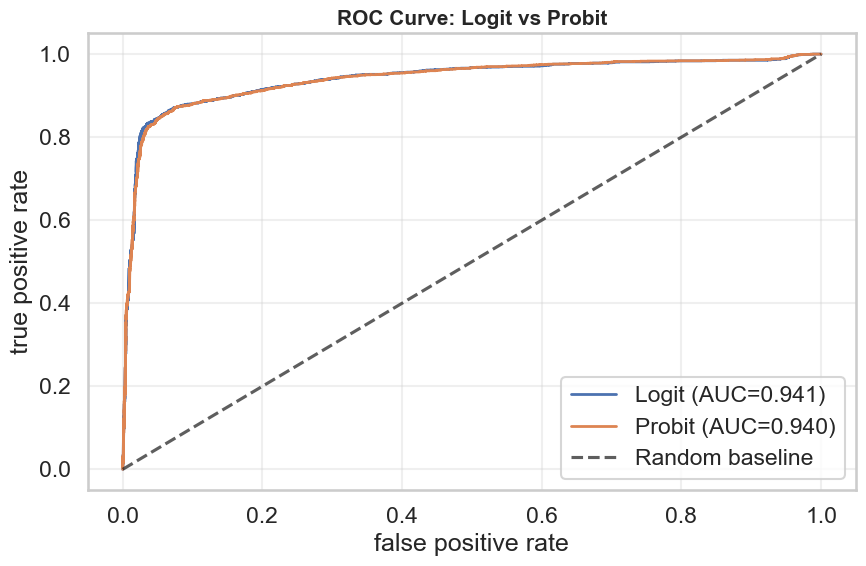

saved: figs/roc_logit_probit.png


In [13]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(auc_payload["fpr_logit"], auc_payload["tpr_logit"], linewidth=2, label=f"Logit (AUC={auc_payload['auc_logit']:.3f})")
ax.plot(auc_payload["fpr_probit"], auc_payload["tpr_probit"], linewidth=2, label=f"Probit (AUC={auc_payload['auc_probit']:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.7, label="Random baseline")
ax.set_title("ROC Curve: Logit vs Probit", fontsize=15, weight="bold")
ax.set_xlabel("false positive rate")
ax.set_ylabel("true positive rate")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
saved_path = save_figure(fig, "roc_logit_probit.png")
plt.show()
print(f"saved: {saved_path.relative_to(project_root)}")


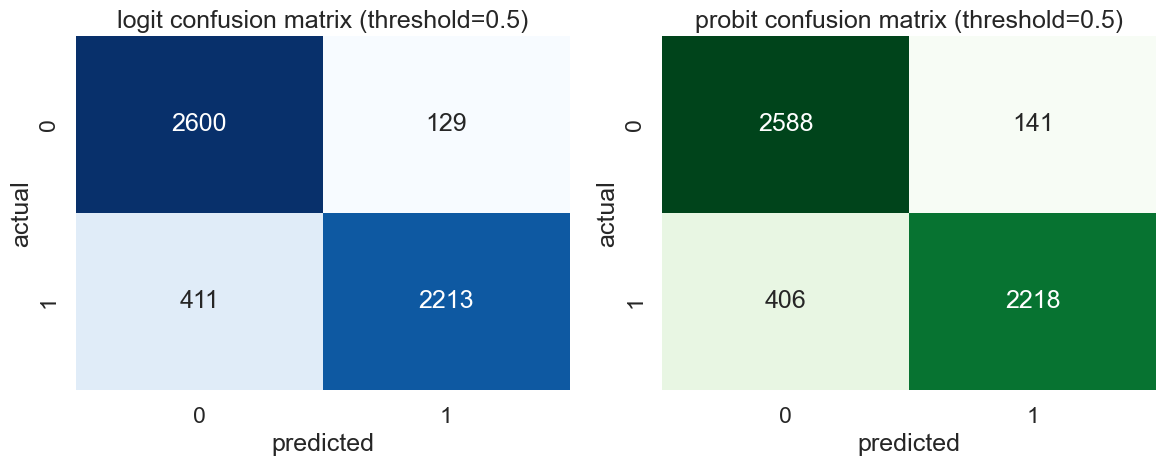

saved: figs/confusion_logit_probit.png


,tn,fp,fn,tp,accuracy,precision,recall,specificity,f1
logit,2600.0,129.0,411.0,2213.0,0.899122,0.944919,0.843369,0.952730,0.891261
probit,2588.0,141.0,406.0,2218.0,0.897814,0.940229,0.845274,0.948333,0.890227


In [14]:
cm_logit = confusion_matrix_df(auc_payload["y_true"], bundle.logit_prob, threshold=0.5)
cm_probit = confusion_matrix_df(auc_payload["y_true"], bundle.probit_prob, threshold=0.5)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm_logit, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0])
axes[0].set_title("logit confusion matrix (threshold=0.5)")
axes[0].set_xlabel("predicted")
axes[0].set_ylabel("actual")

sns.heatmap(cm_probit, annot=True, fmt="d", cmap="Greens", cbar=False, ax=axes[1])
axes[1].set_title("probit confusion matrix (threshold=0.5)")
axes[1].set_xlabel("predicted")
axes[1].set_ylabel("actual")

fig.tight_layout()
saved_path = save_figure(fig, "confusion_logit_probit.png")
plt.show()
print(f"saved: {saved_path.relative_to(project_root)}")

metrics_table = pd.DataFrame(
    {
        "logit": compute_confusion_metrics(auc_payload["y_true"], bundle.logit_prob, threshold=0.5),
        "probit": compute_confusion_metrics(auc_payload["y_true"], bundle.probit_prob, threshold=0.5),
    }
).T
metrics_table


In [15]:
logit_metrics = compute_confusion_metrics(auc_payload["y_true"], bundle.logit_prob, threshold=0.5)
probit_metrics = compute_confusion_metrics(auc_payload["y_true"], bundle.probit_prob, threshold=0.5)

threshold_grid = np.arange(0.30, 0.71, 0.05)
threshold_scan_rows = []
for threshold in threshold_grid:
    metrics = compute_confusion_metrics(auc_payload["y_true"], bundle.logit_prob, threshold=float(threshold))
    threshold_scan_rows.append(
        {
            "threshold": float(threshold),
            "accuracy": metrics["accuracy"],
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "specificity": metrics["specificity"],
            "f1": metrics["f1"],
        }
    )

threshold_scan = pd.DataFrame(threshold_scan_rows)
best_f1_row = threshold_scan.loc[threshold_scan["f1"].idxmax()]
high_recall_row = threshold_scan.loc[threshold_scan["recall"].idxmax()]

summary = f"""
Both models discriminate strongly (**logit AUC={auc_payload['auc_logit']:.4f}**, **probit AUC={auc_payload['auc_probit']:.4f}**), and 0.5-threshold confusion profiles are near-identical.  
At threshold **0.50**, logit precision/recall are **{logit_metrics['precision']:.3f}/{logit_metrics['recall']:.3f}**; probit is **{probit_metrics['precision']:.3f}/{probit_metrics['recall']:.3f}**.  
Threshold tuning matters: best F1 in this scan occurs near **{best_f1_row['threshold']:.2f}** (F1 **{best_f1_row['f1']:.3f}**), while max-recall behavior appears near **{high_recall_row['threshold']:.2f}** (recall **{high_recall_row['recall']:.3f}**, lower specificity **{high_recall_row['specificity']:.3f}**).
"""
display(Markdown(summary))
threshold_scan.round(3)



Both models discriminate strongly (**logit AUC=0.9409**, **probit AUC=0.9404**), and 0.5-threshold confusion profiles are near-identical.  
At threshold **0.50**, logit precision/recall are **0.945/0.843**; probit is **0.940/0.845**.  
Threshold tuning matters: best F1 in this scan occurs near **0.40** (F1 **0.894**), while max-recall behavior appears near **0.30** (recall **0.887**, lower specificity **0.880**).


,threshold,accuracy,precision,recall,specificity,f1
0,0.30,0.883,0.876,0.887,0.880,0.882
1,0.35,0.896,0.911,0.874,0.918,0.892
2,0.40,0.899,0.927,0.862,0.935,0.894
3,0.45,0.899,0.937,0.851,0.945,0.892
4,0.50,0.899,0.945,0.843,0.953,0.891
5,0.55,0.899,0.951,0.837,0.959,0.890
6,0.60,0.899,0.958,0.831,0.965,0.890
7,0.65,0.898,0.963,0.824,0.970,0.888
8,0.70,0.895,0.967,0.813,0.973,0.883


## 7) figure export audit (git-ready)


In [16]:
figure_manifest = pd.DataFrame({"figure": EXPECTED_FIGURES})
figure_manifest["exists"] = figure_manifest["figure"].map(lambda name: (figs_dir / name).exists())
figure_manifest["size_kb"] = figure_manifest["figure"].map(
    lambda name: round((figs_dir / name).stat().st_size / 1024, 1) if (figs_dir / name).exists() else np.nan
)
figure_manifest["path"] = figure_manifest["figure"].map(lambda name: str((figs_dir / name).relative_to(project_root)))
display(figure_manifest)

missing = figure_manifest.loc[~figure_manifest["exists"], "figure"].tolist()
if missing:
    raise FileNotFoundError(f"Missing exported figures: {missing}")

print("All expected figures were exported under figs/ and are ready to commit.")


,figure,exists,size_kb,path
0,finish_rate_trend.png,True,94.3,figs/finish_rate_trend.png
1,division_finish_heatmap.png,True,443.6,figs/division_finish_heatmap.png
2,division_outcome_mix.png,True,305.9,figs/division_outcome_mix.png
3,model_calibration.png,True,171.7,figs/model_calibration.png
4,roc_logit_probit.png,True,128.9,figs/roc_logit_probit.png
5,confusion_logit_probit.png,True,82.2,figs/confusion_logit_probit.png


All expected figures were exported under figs/ and are ready to commit.


## 8) decision takeaway

For your UFC finish-rate repository, the strongest story is structural segmentation rather than time drift. Division identity and in-fight activity proxies separate finish-heavy from decision-heavy environments better than year effects. Model family choice (logit vs probit) is a low-impact decision here; threshold policy is where you gain practical edge.

If the immediate goal is stronger personalized analysis quality, the next upgrades are:
- add fighter-level priors (age curve, layoff length, stance, ranking tier)
- run rolling out-of-time validation instead of in-sample evaluation only
- calibrate thresholds to your use case explicitly (content planning, betting signal triage, or matchup screening)
